<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   income       10 non-null     int64 
 1   loan_amount  10 non-null     int64 
 2   education    10 non-null     object
 3   default      10 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 452.0+ bytes


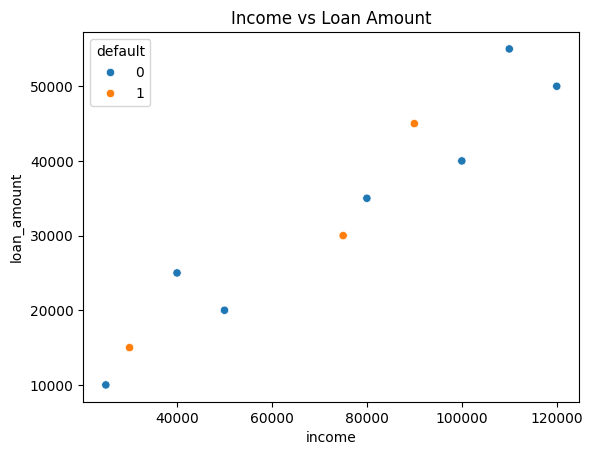

Accuracy: 0.5
[[1 0]
 [1 0]]


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
data = {
    'income': [25000, 50000, 75000, 100000, 120000, 30000, 40000, 80000, 90000, 110000],
    'loan_amount': [10000, 20000, 30000, 40000, 50000, 15000, 25000, 35000, 45000, 55000],
    'education': ['Graduate', 'Graduate', 'Not Graduate', 'Graduate', 'Graduate',
                  'Not Graduate', 'Graduate', 'Graduate', 'Not Graduate', 'Graduate'],
    'default': [0, 0, 1, 0, 0, 1, 0, 0, 1, 0]
}

df = pd.DataFrame(data)
df
df.head()
df.info()
df['education']=df['education'].map({'Graduate':1, 'Not Graduate':0})
df
sns.scatterplot(x='income', y='loan_amount', hue='default', data=df)
plt.title("Income vs Loan Amount")
plt.show()
X = df[['income', 'loan_amount', 'education']]
y = df['default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
cm = confusion_matrix(y_test, y_pred)
print(cm)